# Example 3: Deep Formulas

The orignal Kolmogorov-Arnold theorem says that it suffices to have 2-Layer function composition (inner and outer functions), but the functions might be non-smooth or even fractal. We generalize KA representation to arbitrary depths. An example a 2-Layer KAN (with smooth activations) is unable to do is: $f(x_1,x_2,x_3,x_4)={\rm exp}({\rm sin}(x_1^2+x_2^2)+{\rm sin}(x_3^2+x_4^2))$, which requires at least 3-Layer KANs.

### Three-layer KAN

In [1]:
from kan import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,1,1], grid=3, k=3, seed=1, device=device)
f = lambda x: torch.exp(torch.sin(torch.pi * x[:,0]) + x[:,1]**2)
dataset = create_dataset(f, n_var=4, train_num=3000, device=device)

# train the model
model.fit(dataset, opt="LBFGS", steps=20, lamb=0.002, lamb_entropy=2.);

cpu
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.24e-02 | test_loss: 2.24e-02 | reg: 1.17e+01 | : 100%|█| 20/20 [00:02<00:00,  7.07it

saving model version 0.1


In [2]:
model = model.prune(edge_th=1e-2)

saving model version 0.2


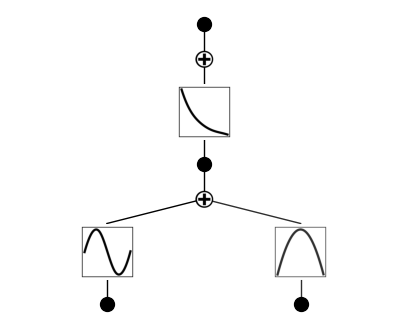

In [3]:
model.plot()

In [4]:
grids = [3,5,10,20,50]
#grids = [5]

train_rmse = []
test_rmse = []

for i in range(len(grids)):
    #model = KAN(width=[4,2,1,1], grid=grids[i], k=3, seed=0, device=device).initialize_from_another_model(model, dataset['train_input'])
    model = model.refine(grids[i])
    results = model.fit(dataset, opt="LBFGS", steps=50, stop_grid_update_step=20);
    train_rmse.append(results['train_loss'][-1].item())
    test_rmse.append(results['test_loss'][-1].item())

saving model version 0.3


| train_loss: 1.64e-02 | test_loss: 1.57e-02 | reg: 1.19e+01 | : 100%|█| 50/50 [00:04<00:00, 11.62it


saving model version 0.4
saving model version 0.5


| train_loss: 5.65e-03 | test_loss: 5.67e-03 | reg: 1.19e+01 | : 100%|█| 50/50 [00:02<00:00, 20.10it


saving model version 0.6
saving model version 0.7


...

saving model version 0.8
saving model version 0.9


| train_loss: 9.44e-05 | test_loss: 1.17e-04 | reg: 1.19e+01 | : 100%|█| 50/50 [00:04<00:00, 10.54it


saving model version 0.10
saving model version 0.11


| train_loss: 3.55e-05 | test_loss: 1.30e-04 | reg: 1.19e+01 | : 100%|█| 50/50 [00:07<00:00,  7.08it

saving model version 0.12


Author's note: The scaling isn't optimal. Possibly because of updates on curve2coef, to be investigated. 

[0.016448475420475006, 0.005653605796396732, 0.0003464937035460025, 9.438564302399755e-05, 3.545853905961849e-05]
[0.01571337692439556, 0.0056709786877036095, 0.00036731152795255184, 0.00011719328904291615, 0.00013025334919802845]


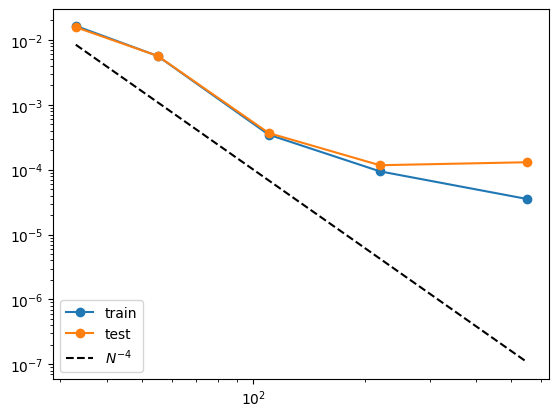

In [5]:
import numpy as np
import matplotlib.pyplot as plt

n_params = np.array(grids) * (4*2+2*1+1*1)
plt.plot(n_params, train_rmse, marker="o")
plt.plot(n_params, test_rmse, marker="o")
plt.plot(n_params, 10000*n_params**(-4.), color="black", ls="--")
plt.legend(['train', 'test', r'$N^{-4}$'], loc="lower left")
plt.xscale('log')
plt.yscale('log')
print(train_rmse)
print(test_rmse)

### Two-layer KAN

Now we show that a 2 two-layer KAN performs much worse for this task

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 5.03e-01 | test_loss: 5.03e-01 | reg: 3.40e+00 | : 100%|█| 20/20 [00:00<00:00, 46.00it


saving model version 0.1
saving model version 0.2


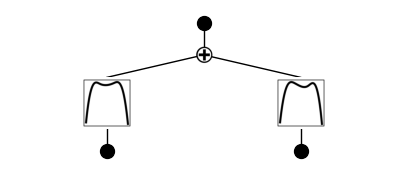

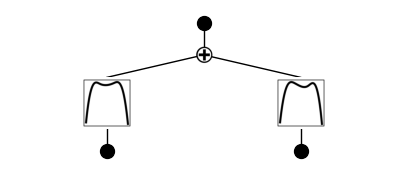

In [6]:
from kan import KAN, create_dataset
import torch

# create a KAN: 2D inputs, 1D output, and 5 hidden neurons. cubic spline (k=3), 5 grid intervals (grid=5).
model = KAN(width=[2,1], grid=3, k=3, seed=0)
f = lambda x: torch.exp((torch.sin(torch.pi*(x[:,[0]]**2+x[:,[1]]**2))+torch.sin(torch.pi*(x[:,[2]]**2+x[:,[3]]**2)))/2)
dataset = create_dataset(f, n_var=4, train_num=3000)

# train the model
model.fit(dataset, opt="LBFGS", steps=20, lamb=0.002, lamb_entropy=2.);
model.plot(beta=10)
model.prune()
model.plot(beta=10)

In [7]:
grids = [3,5,10,20,50]

train_rmse = []
test_rmse = []

for i in range(len(grids)):
    #model = KAN(width=[4,9,1], grid=grids[i], k=3, seed=0).initialize_from_another_model(model, dataset['train_input'])
    model = model.refine(grids[i])
    results = model.fit(dataset, opt="LBFGS", steps=50, stop_grid_update_step=30);
    train_rmse.append(results['train_loss'][-1].item())
    test_rmse.append(results['test_loss'][-1].item())

saving model version 0.2


| train_loss: 5.03e-01 | test_loss: 5.03e-01 | reg: 3.42e+00 | : 100%|█| 50/50 [00:00<00:00, 64.69it


saving model version 0.3
saving model version 0.4


| train_loss: 5.02e-01 | test_loss: 5.00e-01 | reg: 3.43e+00 | : 100%|█| 50/50 [00:01<00:00, 40.68it


saving model version 0.5
saving model version 0.6


...

saving model version 0.7
saving model version 0.8


| train_loss: 4.99e-01 | test_loss: 5.01e-01 | reg: 3.45e+00 | : 100%|█| 50/50 [00:01<00:00, 34.58it


saving model version 0.9
saving model version 0.10


| train_loss: 4.94e-01 | test_loss: 5.06e-01 | reg: 3.48e+00 | : 100%|█| 50/50 [00:02<00:00, 20.86it

saving model version 0.11


[0.5026392936706543, 0.5018371939659119, 0.4997144341468811, 0.49875912070274353, 0.4942891001701355]
[0.5034897923469543, 0.49982893466949463, 0.4988827705383301, 0.5010868310928345, 0.5060988068580627]


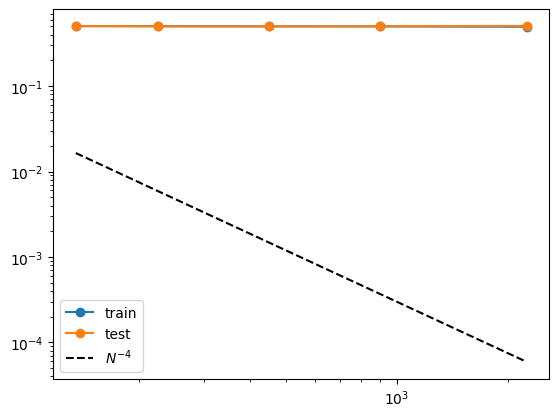

In [8]:
import numpy as np
import matplotlib.pyplot as plt

n_params = np.array(grids) * (4*9+9*1)
plt.plot(n_params, train_rmse, marker="o")
plt.plot(n_params, test_rmse, marker="o")
plt.plot(n_params, 300*n_params**(-2.), color="black", ls="--")
plt.legend(['train', 'test', r'$N^{-4}$'], loc="lower left")
plt.xscale('log')
plt.yscale('log')
print(train_rmse)
print(test_rmse)